# Module 8

## Machine learning using scikit-learn

- Scikit-Learn provides efficient versions of a large number of common algorithms for:
    - Classification
    - Regression
    - Clustering
    - Dimensionality reduction
    - Model selection
    - Preprocessing
- Uniform interface: once you understand the basic for one type of model, switching to a new model or algorithm is very straightforward
- Well written documentations: [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme() ## this sets some style parameters

# To check version of sklearn, run the following command in your terminal:
# python -c "import sklearn; print(sklearn.__version__)"


Dataset loading and merging: ``df_subj_FA``

In [2]:
df_MRI = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/regression_data/nodes.csv?raw=true')
df_subj = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/regression_data/subjects.csv?raw=true')

df_MRI["tractID"] = df_MRI["tractID"].replace(" ", "_", regex=True)

# Transform dataset in data analysis friendly format (see Module 7)
df_FA_summary = df_MRI.groupby(["subjectID","tractID"])[["fa"]].mean().reset_index()
df_FA_summ_wide = df_FA_summary.pivot(index=["subjectID"], columns="tractID", values="fa")

df_subj_FA_wth_NA = pd.merge(df_subj, df_FA_summ_wide, on="subjectID")
df_subj_FA = df_subj_FA_wth_NA.fillna(df_subj_FA_wth_NA.mean(numeric_only=True)) # fill missing values with mean of each column
df_subj_FA = df_subj_FA.drop(columns=['Unnamed: 0', 'subjectID'])

print(f"Shape of df_subj_FA: {df_subj_FA.shape}")
print(df_subj_FA.head(n = 3))



Shape of df_subj_FA: (77, 26)
   Age  Gender Handedness     IQ  IQ_Matrix  IQ_Vocab  Callosum_Forceps_Major  \
0   20    Male        NaN  139.0       65.0      77.0                0.613832   
1   31    Male        NaN  129.0       58.0      74.0                0.635702   
2   18  Female        NaN  130.0       63.0      70.0                0.667058   

   Callosum_Forceps_Minor  Left_Arcuate  Left_Cingulum_Cingulate  ...  \
0                0.521800      0.501179                 0.534352  ...   
1                0.520765      0.493810                 0.497789  ...   
2                0.531988      0.501383                 0.494697  ...   

   Left_Uncinate  Right_Arcuate  Right_Cingulum_Cingulate  \
0       0.444197       0.494026                  0.496042   
1       0.448121       0.467065                  0.487729   
2       0.428530       0.520190                  0.477047   

   Right_Cingulum_Hippocampus  Right_Corticospinal  Right_IFOF  Right_ILF  \
0                    0.421556 

In ``sklearn``, we typically we work with two objects:
- **Features matrix** (``X``): two-dimensional, with shape ``[n_samples, n_features]``. Usually a NumPy array or a Pandas ``DataFrame``. Features are generally real-valued, but may be Boolean or discrete-valued in some cases. number of samples by number of features 
- **Target array** (``y``): *label* or *target*, with length ``n_samples``. Usually a NumPy array or Pandas ``Series``. The target array may have continuous numerical values, or discrete classes/labels. 

formulas are a little more difficult to work with 

In [3]:
X_FA = df_subj_FA.drop(columns = ['Age', 'Gender', 'Handedness', 'IQ', 'IQ_Matrix', 'IQ_Vocab']) #drop all columns that I dont want to use as a predictor 
#77 by 20 matrix
#77 is number of subjects by number of predictors 
X_FA.shape


(77, 20)

In [ ]:
y = df_subj_FA['Age']
y.shape
#age for all these subjects (77)

(77,)

### Basics of sklearn

1. Choose a class of models by importing the appropriate ``estimator`` class from Scikit-Learn. (estimator means model in sklearn)
2. Choose model hyperparameters by instantiating this class with desired values. (model with or without intercept, those would be decided)
3. Arrange data into a features matrix and target vector.
4. Fit the ``estimator`` to your data by calling the ``fit()`` method.
5. Apply the model to new data:
   - For supervised learning, often we predict labels for unknown data using the ``predict()`` method.
   - For unsupervised learning, we often transform or infer properties of the data using the ``fit_transform()`` or ``predict()`` method.

### Supervised learning example I: Linear regression

As an example, let's consider a linear regression.

#### 1. Choose a class of model

In [6]:
from sklearn.linear_model import LinearRegression

#choose linear model 

Note that other more general linear regression models exist as well; you can read more about them in the [``sklearn.linear_model`` module documentation](http://Scikit-Learn.org/stable/modules/linear_model.html).

#### 2. Choose model hyperparameters

In Scikit-Learn, hyperparameters are chosen by passing values at model instantiation.

For our linear regression example, we can instantiate the ``LinearRegression`` class and specify that we would like to fit the intercept using the ``fit_intercept`` hyperparameter:

In [10]:
model_lin = LinearRegression(fit_intercept=True) #default choice anyways, making explicit i am going to define LR model where there model fit itnercept is also fit to the data 
model_lin


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
model_lin.get_params() #gives same output but in the form of a dictionary 

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

Keep in mind that when the model is instantiated, the only action is the storing of these hyperparameter values.

In particular, we have not yet applied the model to any data: ``sklearn`` makes very clear the distinction between the *choice of model* and the *application of model to data*.

#### 3. Arrange the data into a feature matrix and target vector, then split into training and test sets.


In [ ]:
from sklearn.model_selection import train_test_split #automatically splits data set 
#size of training variable you want 
#random seed = 0 

print(f"Shape of X: {X_FA.shape}")
print(f"Shape of y: {y.shape}")

#want model to work well on a data it hasnt seen before 
#train data is used to create model 
#test is unseen data and see how well model works on unseen data 

# You can do it by hand or using train_test_split
# X_FA_train = X_FA[1:50]
# y_train = y[1:50]
# X_FA_test = X_FA[50:]
# y_test = y[50:]

X_FA_train, X_FA_test, y_train, y_test = train_test_split(X_FA, y, 
                                                          train_size=50,
                                                          random_state=0)
print(f"Shape of X (train): {X_FA_train.shape}")
print(f"Shape of y (train): {y_train.shape}")
print(f"Shape of X (test): {X_FA_test.shape}")
print(f"Shape of y (test): {y_test.shape}")

#end up with four data sets, with train being made up of 50 observations and test being the remaining data set 


Shape of X: (77, 20)
Shape of y: (77,)
Shape of X (train): (50, 20)
Shape of y (train): (50,)
Shape of X (test): (27, 20)
Shape of y (test): (27,)


#### 4. Fit the model to your data

Now it is time to apply our model to the data. This can be done with the ``fit()`` method of the model.

In [ ]:
model_lin.fit(X_FA_train, y_train)

#making computation and adding relevant information 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The `fit()` command performs a number of model-dependent internal computations, and the results of these computations are stored in model-specific attributes that the user can explore.

In Scikit-Learn, by convention, all model parameters learned during the `fit()` process have trailing underscores. For example, in this linear model, we have the following:

In [ ]:
model_lin.coef_
#provides coef 
#if it is followed by _ then it is something that is computed by model fit 

array([  54.70357076,  -26.07110623,  -88.42102977,   49.90171116,
         31.87281496,   21.27157054,  101.2312978 ,   59.85088716,
         40.65771107,   -3.39840485, -100.41415897,  -90.78510114,
        137.40157557,  106.0933151 ,   23.64195313, -215.28776929,
       -130.96737094,   82.42736228,   78.23583018,  139.30429413])

In [ ]:
model_lin.intercept_
#provides intercept 

np.float64(-96.89195618598472)

In general, Scikit-Learn does not provide tools for inference; instead, it focuses on prediction. For inference, we can use `statsmodels`.

#### 5. Predict labels for unknown data

Once the model is trained, the main task of supervised machine learning is to evaluate it based on predictions for new data that was not part of the training set.

In Scikit-Learn, this can be done using the `predict()` method.

In [15]:
y_train_fit = model_lin.predict(X_FA_train)
y_test_fit = model_lin.predict(X_FA_test)


print(f"Shape y (train) fit: {y_train_fit.shape}")
print(f"Shape y (test) fit:  {y_test_fit.shape}")

Shape y (train) fit: (50,)
Shape y (test) fit:  (27,)


Finally, let's visualize the results by plotting first the raw data, and then this model fit:

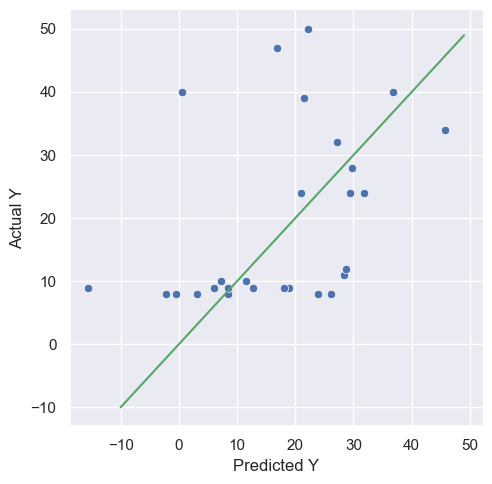

In [ ]:
sns.relplot(x=y_test_fit, y = y_test)
sns.lineplot(x=np.arange(-10, 50, 1), y=np.arange(-10, 50, 1), color='g')
plt.ylabel("Actual Y")
plt.xlabel("Predicted Y");

#compare fitted values to true values 
#model is not great 
#overview of how model works 


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
#use metrics to assess error and performance of predictive model 

print(f"Train MSE: {mean_squared_error(y_train, y_train_fit)}; Train R^2: {r2_score(y_train, y_train_fit)}")

# on training error mean squared error ris 46 not meaningful on own 
#r squared 62% of variance explained by covariates 
#easy to get high r2 on model that it was using the data to create 

Train MSE: 46.28670360538271; Train R^2: 0.6276342301207141


In [ ]:
print(f"Test MSE: {mean_squared_error(y_test, y_test_fit)}; Test R^2: {r2_score(y_test, y_test_fit)}")

#negative r2, r2 is between 0 and 1 unless you apply model to unseen data 
# negative value means predicting with mean would be better than your model 
#model is over fitting 
#over fitting is when you are doing well, but you might have just learned an error foudn out that there is something that doesnt work well for unseen data, translating to noise 
# under fitting, model doesnt work well on training data and test data 
#

Test MSE: 222.15841581233835; Test R^2: -0.16004215405196365


### Model validation

- Linear regression does not appear to perform well, so we will move away from this model.
- However, when evaluating several `estimators` (models), or different `hyperparameters` (settings of a given model), there is a risk of overfitting to the test set.
- This can happen when model choices or hyperparameters are repeatedly tweaked until the estimator performs optimally on the test set.
- As a result, the reported performance is no longer representative of how well the model will perform on new data once deployed.

To solve this problem, we can use one of the following strategies:

- Hold out another part of the dataset as a **validation set**:
  - Training is performed on the training set.
  - Model selection is performed using the validation set.
  - Final evaluation is performed once on the test set.
- Use **cross-validation**:
  - Cross-validation performs a sequence of fits in which each subset of the data is used both as a training set and as a validation set.

Visually, it looks something like this:

<div style="text-align: center;">
  <img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width="400">
</div>


have to guess how well test data will perform using the training data by splitting the training into train and validation 

split 1 - four folds for trianing and 1 on test 
split 2 - four folds for training and 1 on test 

cross validation should be done on trainign data, the test data is carved out initially and thrown out on the side, after you picked out the best model, test the performance of the best model
get an estimate of the performance in the test data without spoiling test data 


**Question**: Could I have guessed, using only the training data, that linear regression was going to perform poorly on unseen data?

yes by using cross validation 

In [ ]:
from sklearn.model_selection import cross_val_score
val_scores = cross_val_score(model_lin, X_FA_train, y_train, cv=10, scoring='r2')  #10 folds, metric you are going to use to measure 
val_scores.shape #each one of the runs will give us the r2 for each split 

(10,)

In [ ]:
print(f"Train R^2: {r2_score(y_train, y_train_fit):3.2f}")
print(f"Validation R^2: {cross_val_score(model_lin, X_FA_train, y_train, cv=10).mean():3.2f}") #average across the ten folds 
print(f"Test R^2: {r2_score(y_test, y_test_fit):3.2f}") #normally wouldnt touch test until the very end 

#cross validation is a better tool for predicting how well test data will perform 

Train R^2: 0.63
Validation R^2: -1.51
Test R^2: -0.16


### Selecting the best model

Now that we have seen the basics of validation and cross-validation, we will look more closely at model selection and hyperparameter selection.

In general, model selection involves deciding whether to use:

- a more complicated, more flexible model - under fitting fix 
- a less complicated, less flexible model - over fitting fix 

Finding the “best” model is about balancing *bias* and *variance*.

- **Underfitting** = high bias, low variance
- **Overfitting** = low bias, high variance

Simple linear regression does not allow us to explicitly control model complexity. However, its extension, **Lasso regression**, does.

Lasso solves the following problem:

$$
\hat{\beta}
=
\arg\min_{\beta}
\left[
\frac{1}{2n} \lVert y - X\beta \rVert_2^2
+
\alpha \lVert \beta \rVert_1
\right]
$$

Here, $\alpha$ controls the strength of regularization:

- larger $\alpha$ → simpler model with more shrinkage, more rigid 
- smaller $\alpha$ → more flexible model with less shrinkage

one side looks like least squares but you have a penalty term predict outcome when alpha is 0 then its classic LR if alpha is large then 


In [ ]:
from sklearn.linear_model import Lasso  #a part of the linear model but sub type of lasso 

# Create a Lasso model
model_lasso = Lasso(alpha=0.0001) #hyper parameter of lasso decides how flexible lasso is, alpha very small lasso becomes basically linear regression, if you make lasso larger then r2 gets lower 
# Fit model to data 
model_lasso.fit(X_FA_train, y_train) #fit model to training data 

y_train_fit = model_lasso.predict(X_FA_train) #get r2 on training data 

print(f"Train R^2: {r2_score(y_train, y_train_fit)}")

#lasso takes in a parameter (alpha) allows me to underfit data, doesnt make a lot of sense on seen data but may be better on unseen data
#less complex model doesnt help on the seen data but most liekly will on unseen 
#r2 may not be the best metric 

Train R^2: 0.6276206806705279


It may be tempting to check performance on the test set and optimize the choice of `alpha` based on that performance, but this should be avoided. Instead we use crossvalidation on training data.

In [46]:
model = Lasso(alpha = 0.001)

# Perform cross-validation (e.g., with 5 folds) using mean squared error
r2_val_scores = cross_val_score(model, X_FA_train, y_train, cv=10, scoring="r2")

print("Validation MSE:",r2_val_scores.mean())

Validation MSE: -1.3037618849952515


Let's explore more systematically how the choice of `alpha` affects training error and cross-validated error.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import validation_curve  #tool to specify a grid of alphas you care about

# Candidate alpha values for Lasso
alpha_grid = np.logspace(-4, 2, 50) #uniform grid of potential alphas 

model = Lasso(max_iter=10000)

train_r2, val_r2 = validation_curve(
    model,
    X_FA_train,
    y_train,
    param_name="alpha",
    param_range=alpha_grid,
    cv=10,
    scoring="r2"
)

val_r2.shape

(50, 10)

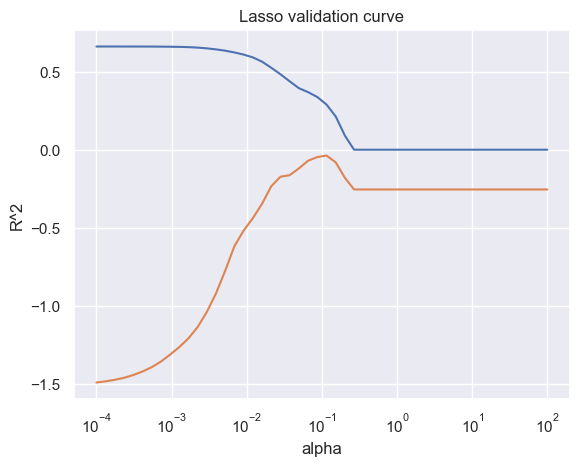

In [ ]:
plt.semilogx(alpha_grid, np.mean(train_r2, axis=1), label="training MSE")
plt.semilogx(alpha_grid, np.mean(val_r2, axis=1), label="validation MSE")

plt.xlabel("alpha")
plt.ylabel("R^2")
plt.title("Lasso validation curve")
plt.show()

#different choices for parameters of alpha, we check training error in blue, by making model more rigid it gets worse 
#there is a level of alpha that works in this case 

In [ ]:
# Optimal hyperparameter

best_alpha = alpha_grid[val_r2.mean(axis=1).argmax()]

# Compute test MSE for the best alpha value
model_lasso_best = Lasso(alpha=best_alpha, max_iter=10000)

# For demonstration purposes only, let's check the test error WOULD NOT DO THIS UNTIL THE LAST STEP IN REAL LIFE 
y_test_fit = model_lasso_best.fit(X_FA_train, y_train).predict(X_FA_test)
print(f"Test R^2: {r2_score(y_test, y_test_fit)}")

#.16 is left from 27 observation, want to be careful, but looks like we are going into the right direction 

Test R^2: 0.1684507694557298


### Validation in practice: grid search

Using `validation_curve` was meant to give you some intuition about the trade-off between bias and variance.

In practice, models generally have more than one hyperparameter to tune, so plots of validation and learning curves change from lines to multidimensional surfaces, which are difficult to visualize.

Scikit-Learn provides automated tools for hyperparameter search (meta-estimators), including the `GridSearchCV`

In [50]:
from sklearn.model_selection import GridSearchCV 

param_grid_lasso = {'alpha': alpha_grid,
                    'fit_intercept': [True, False]} #define parameters of model selection can also play around with whether or not you want to use a model with a fitted intercept or not 

lasso_lin =Lasso(max_iter=10000)
grid = GridSearchCV(Lasso(max_iter=10000), param_grid_lasso, cv=10, refit=True, scoring='r2') 


Notice that like any sklearn estimator, this has not yet been applied to any data.
Calling the ``fit()`` method will fit the model at each grid point, keeping track of the scores along the way:

In [51]:
grid.fit(X_FA_train, y_train)

c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.888e+02, tolerance: 2.014e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.081e+03, tolerance: 2.153e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(max_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([1.0000...00000000e+02]), 'fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

Now that the model has been fit, we can retrieve the best parameters.

In [ ]:
grid.best_params_

#alpha = to 0.03 with combined with a model that doesnt use intercept 

{'alpha': np.float64(0.03727593720314938), 'fit_intercept': False}

In [ ]:
grid.best_score_

#in the realm of positive r2

np.float64(0.021455071501435875)

Or we can directly retrieve the best model.

Test R^2: 0.3318216789509293


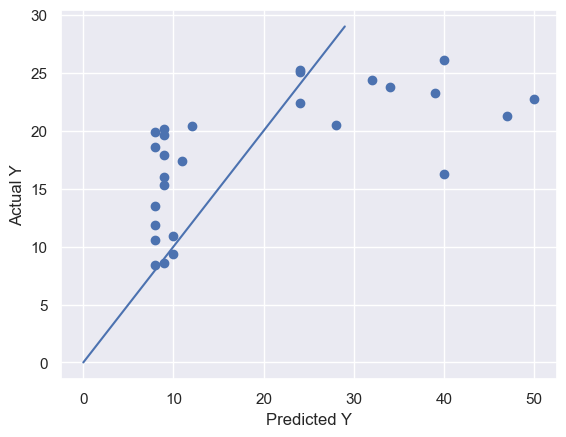

In [54]:
# For demonstration purposes only, let's check the test error

model_lasso_best = grid.best_estimator_ #get best model/estimator 

y_test_fit = model_lasso_best.fit(X_FA_train, y_train).predict(X_FA_test)
plt.scatter(y_test, y_test_fit)
plt.plot(np.arange(0,30,1), np.arange(0,30,1))
plt.ylabel("Actual Y")
plt.xlabel("Predicted Y");

# Suspicious! We have a tiny test set here
print(f"Test R^2: {r2_score(y_test, y_test_fit)}")

#see how well it works on test data 

### Defining a pipeline by combining models and/or preprocessing steps

For instance, with Lasso regression, it is often advised to standardize the features of your regression matrix so that the penalty is applied fairly across features.

This matters because Lasso penalizes the size of the coefficients. If features are measured on very different scales, then the penalty can affect some coefficients more strongly than others simply because of the units of measurement.


In [60]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Candidate alpha values for Lasso
alpha = np.logspace(-4, 2, 50)

# Lasso works better when features are scaled
#first step scale variable to have variance 1 
model_std_lasso = make_pipeline(
    StandardScaler(),
    Lasso(max_iter=10000)
)
#lasso sensitive to units of variables 
#but if you are working with things like age, makes sense to standardize variable 

model_std_lasso.named_steps

{'standardscaler': StandardScaler(), 'lasso': Lasso(max_iter=10000)}

In [61]:
param_grid_std_lasso = {
              'lasso__alpha': alpha_grid,
              'lasso__fit_intercept': [True, False]} #refer to subunit of model need double _ (__) take alpha inside lasso unit 
#need to refer to which subunit of the analysis you are using 

grid = GridSearchCV(model_std_lasso, param_grid_std_lasso, cv=10, scoring='r2')

grid.fit(X_FA_train, y_train)

#get "errors" because some combinations wont work well 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': array([1.0000...00000000e+02]), 'lasso__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [ ]:
print(grid.best_params_) #gives value of parameters that maximize the alphas score
print(grid.best_score_)

#doesnt look like its giving us a much better feature 

{'alpha': np.float64(0.03727593720314938), 'fit_intercept': False}
0.021455071501435875


Test R^2: 0.15445496273262138


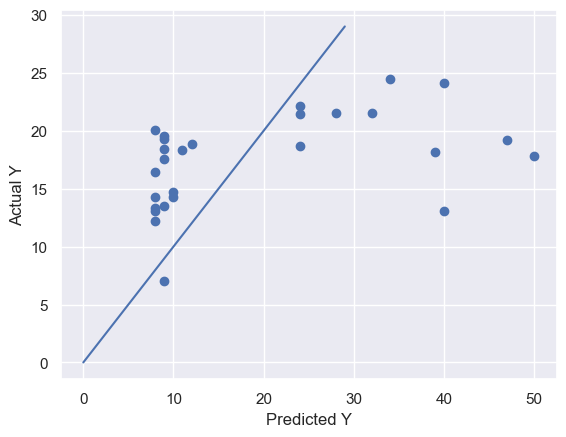

In [34]:
# For demonstration purposes only, let's check the test error

model_std_lasso_best = grid.best_estimator_

y_test_fit = model_std_lasso_best.fit(X_FA_train, y_train).predict(X_FA_test)
plt.scatter(x = y_test, y = y_test_fit)
plt.plot(np.arange(0,30,1), np.arange(0,30,1))
plt.ylabel("Actual Y")
plt.xlabel("Predicted Y");

print(f"Test R^2: {r2_score(y_test, y_test_fit)}")

### Feature Engineering

The previous sections outlined the main steps of a supervised analysis, assuming numerical data in a tidy `[n_samples, n_features]` format. In the real world, data may come in different forms, such as unstructured data.

One way to deal with this is through *feature engineering*: creating numerical features from raw data in order to build a feature matrix.

Here, we will look at one special case: creating additional features from existing numerical features, for instance by adding polynomial and interaction terms.

In [35]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_FA_extended = poly.fit_transform(X_FA)

print(f"From {X_FA.shape} to {X_FA_extended.shape}")

From (77, 20) to (77, 230)


For degree 2, and for each pair of features $x_1$ and $x_2$, the `PolynomialFeatures` transform adds features representing $x_1^2$, $x_2^2$, and $x_1x_2$.

In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Candidate alpha values for Lasso
alpha_grid = np.logspace(-4, 2, 50)

# Lasso works better when features are scaled
model_std_poly_lasso = make_pipeline(
    PolynomialFeatures(include_bias=False),
    StandardScaler(),
    Lasso(max_iter=10000)
)

model_std_poly_lasso.named_steps

{'polynomialfeatures': PolynomialFeatures(include_bias=False),
 'standardscaler': StandardScaler(),
 'lasso': Lasso(max_iter=10000)}

In [37]:
param_grid_std_poly_lasso = {
              'polynomialfeatures__degree': [1,2],
              'lasso__alpha': alpha_grid,
              'lasso__fit_intercept': [True, False]}

grid = GridSearchCV(model_std_poly_lasso, param_grid_std_poly_lasso, cv=10, scoring="r2", refit=True)
grid.fit(X_FA_train, y_train)

print(grid.best_estimator_)
print(grid.best_score_)


c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.714e+00, tolerance: 5.200e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.048e+01, tolerance: 5.702e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\lsmix\miniconda3\envs\biost506\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

KeyboardInterrupt: 

In [ ]:
# For demonstration purposes only, let's check the test error

model_std_poly_lasso = grid.best_estimator_

y_test_fit = model_std_poly_lasso.predict(X_FA_test)
plt.scatter(x = y_test, y = y_test_fit)
plt.plot(np.arange(0,30,1), np.arange(0,30,1))

print(f"Test R^2: {r2_score(y_test, y_test_fit)}")

### Imputation of Missing Data

Another commonly needed feature in machine learning is the *imputation* of missing values. Several imputation strategies are natively supported in Scikit-Learn.

For baseline imputation approaches, such as using the mean, median, or most frequent value, Scikit-Learn provides the `SimpleImputer` class. Other related classes, such as `KNNImputer`, support more flexible imputation strategies.

In [ ]:
from sklearn.impute import KNNImputer
imp = KNNImputer()

X_FA_wth_NA = df_subj_FA_wth_NA.drop(columns = ['Unnamed: 0', 'subjectID', 'Age', 'Gender', 'Handedness', 'IQ', 'IQ_Matrix', 'IQ_Vocab'])

X_FA_imp = imp.fit_transform(X_FA_wth_NA)
X_FA_imp

The imputed data can then be fed directly into an estimator, such as `LinearRegression`, as part of a `Pipeline`.

### Final regression analysis

For simplicity, we previously summarized measurements at the tract level by reducing 100 measurements to 1. This allowed us to run a simple linear regression.

With Lasso, however, we do not have to reduce the data in this way. Let's run a more involved analysis.

In [ ]:
# Transform dataset
df_FA_HD_wide = df_MRI.pivot(index=["subjectID"], columns=["tractID", "nodeID"] , values="fa")
df_FA_HD_wide.columns = df_FA_HD_wide.columns.to_flat_index()
df_subj_FA_HD = pd.merge(df_subj, df_FA_HD_wide, on="subjectID")
df_subj_FA_HD = df_subj_FA_HD.drop(columns=['Unnamed: 0', 'subjectID'])

X_FA_HD = df_subj_FA_HD.drop(columns = ['Age', 'Gender', 'Handedness', 'IQ', 'IQ_Matrix', 'IQ_Vocab'])

X_FA_HD_train, X_FA_HD_test, y_train, y_test = train_test_split(X_FA_HD, y, 
                                                                train_size=50,
                                                                random_state=0)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

# Let's use Ridge regression instead of Lasso. It's a bit faster but we renounce to the variable selection feature of Lasso

# Candidate alpha values for Ridge
alpha_grid = np.logspace(-4, 2, 50)

# Ridge works better when features are scaled
model_HD_ridge = make_pipeline(
    SimpleImputer(strategy="median"),
    Ridge(max_iter=10000)
)

model_HD_ridge.named_steps

In [ ]:
param_grid_HD = {
              'ridge__alpha': alpha_grid,
              'ridge__fit_intercept': [True, False]}

grid = GridSearchCV(model_HD_ridge, param_grid_HD, cv=10, scoring="r2", refit=True)
grid.fit(X_FA_HD_train, y_train)

print(grid.best_estimator_)
print(grid.best_score_)

In [ ]:
# For demonstration purposes only, let's check the test error

model_HD_ridge_log_age = grid.best_estimator_

y_test_fit = model_HD_ridge_log_age.fit(X_FA_HD_train, y_train).predict(X_FA_HD_test)
plt.scatter(y_test, y_test_fit)
plt.plot(np.arange(0,30,1), np.arange(0,30,1))

# Suspicious! We have a tiny test set here
print(f"Test R^2: {r2_score(y_test, y_test_fit)}")